<a href="https://colab.research.google.com/github/marescost4/Mariane-David-Fillipy/blob/main/tarefa05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bioestatística - atividade 5

- David Souza 16965966
- Mariane Santana 16890981
- Fillipy Leal 17097358




In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('Tarefa_Semana3.xlsx')
df.head (150)

,Bloco,Tratamento,Recipiente,Explante,Brotos,Folhas
0,1,0,1,1,2,6
1,1,0,1,2,1,8
2,1,0,1,3,0,0
3,1,0,1,4,1,0
4,1,0,1,5,2,0
...,...,...,...,...,...,...
115,6,3,4,1,0,0
116,6,3,4,2,2,16
117,6,3,4,3,2,22
118,6,3,4,4,2,0


In [2]:
print ("Número de linhas", len (df))
print ("Número de colunas", len (df.columns))

Número de linhas 120
Número de colunas 6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Bloco       120 non-null    int64
 1   Tratamento  120 non-null    int64
 2   Recipiente  120 non-null    int64
 3   Explante    120 non-null    int64
 4   Brotos      120 non-null    int64
 5   Folhas      120 non-null    int64
dtypes: int64(6)
memory usage: 5.8 KB


In [4]:
df["BAP"] = df["Tratamento"].map({0: "0 mg/L",1: "1 mg/L",2: "2 mg/L",3: "3 mg/L"})

df.head()

,Bloco,Tratamento,Recipiente,Explante,Brotos,Folhas,BAP
0,1,0,1,1,2,6,0 mg/L
1,1,0,1,2,1,8,0 mg/L
2,1,0,1,3,0,0,0 mg/L
3,1,0,1,4,1,0,0 mg/L
4,1,0,1,5,2,0,0 mg/L


Tratamento 0 → 0 mg/L

Tratamento 1 → 1 mg/L

Tratamento 2 → 2 mg/L

Tratamento 3 → 3 mg/L

## 1 - Há observações atípicas dos dados? Qual o valor mínimo e máximo das variáveis? O que elas representam?

R: É visível a presença de alguns valores altos, concentrados nos limites superiores. Para o número de brotos por explante, a variação foi de 0 a 6. A ausência de brotação (0) marca o limite mínimo, enquanto o topo de 6 brotos representa uma resposta acima da média do grupo. No caso do número de folhas, a amplitude variou de 0 a 46 por explante, com contagens como 42 e 46 se destacando do padrão geral e caracterizando pelo critério do intervalo interquartil (IQR).
No entanto, essa observação atípica não sinaliza um erro de digitação por exemplo. Esses picos podem sim tem relação com a resposta da planta ao BAP.


In [5]:
#Observações atípicas, mínimo e máximo.
print("BROTOS")
print("Mínimo:", df["Brotos"].min())
print("Máximo:", df["Brotos"].max())

print("\nFOLHAS")
print("Mínimo:", df["Folhas"].min())
print("Máximo:", df["Folhas"].max())

BROTOS
Mínimo: 0
Máximo: 6

FOLHAS
Mínimo: 0
Máximo: 46


In [6]:
#Valor mínimo e máximo das variáveis
print("Menor número de brotos:")
print(df.loc[df["Brotos"] == df["Brotos"].min()])

print("\nMaior número de brotos:")
print(df.loc[df["Brotos"] == df["Brotos"].max()])

print("\nMenor número de folhas:")
print(df.loc[df["Folhas"] == df["Folhas"].min()])

print("\nMaior número de folhas:")
print(df.loc[df["Folhas"] == df["Folhas"].max()])

Menor número de brotos:
     Bloco  Tratamento  Recipiente  Explante  Brotos  Folhas     BAP
2        1           0           1         3       0       0  0 mg/L
9        1           1           2         5       0       0  1 mg/L
14       1           2           3         5       0       0  2 mg/L
18       1           3           4         4       0       0  3 mg/L
19       1           3           4         5       0       0  3 mg/L
23       2           0           1         4       0       0  0 mg/L
24       2           0           1         5       0       0  0 mg/L
29       2           1           2         5       0       0  1 mg/L
33       2           2           3         4       0       0  2 mg/L
41       3           0           1         2       0       0  0 mg/L
42       3           0           1         3       0       0  0 mg/L
44       3           0           1         5       0       0  0 mg/L
52       3           2           3         3       0       0  2 mg/L
55       3

## 2 - Determina os 2º e 3° quartis para o número de brotos e folhas e o que eles representam.

R: A mediana (Q2) ficou em 2 brotos e 10 folhas, mostrando que metade dos explantes respondeu dentro desse patamar. Já o terceiro quartil (Q3) avançou para 3 brotos e 20 folhas, sinalizando que 75% da amostra acumulou até esses valores.


In [7]:
# 2º e 3º quartis para Brotos e Folhas

quartis = df[["Brotos", "Folhas"]].quantile([0.50, 0.75])

print(quartis)

      Brotos  Folhas
0.50     2.0    10.0
0.75     2.0    18.0


## 3 - Qual é o número médio de brotos e folhas por explante em cada concentração de BAP?

R: O número médio de brotos e folhas variou de acordo com a concentração de BAP. Para brotos, a maior média foi observada em 2 mg (2,33 brotos por explante), seguida de 1 mg (1,87), 3 mg (1,70) e do controle (0,93). Para folhas, a maior média ocorreu em 1 mg (15,00 folhas por explante), seguida de 2 mg (11,70), 3 mg (9,07) e do controle (5,40). Esses resultados indicam que a concentração de BAP que proporcionou maior brotação não foi a mesma que proporcionou maior produção de folhas.

In [8]:
# Média de brotos e folhas por concentração de BAP

medias = df.groupby("Tratamento")[["Brotos", "Folhas"]].mean()

print(medias.round(2))

            Brotos  Folhas
Tratamento                
0             0.93    5.40
1             1.87   15.00
2             2.27   11.70
3             1.70    9.07


In [9]:
#Numero de observações
print("Número de observações:", len(df))
print("\nNúmero de observações por tratamento:")
print(df["Tratamento"].value_counts().sort_index())

print("\nValores ausentes:")
print(df[["Tratamento", "Brotos", "Folhas"]].isnull().sum())

Número de observações: 120

Número de observações por tratamento:
Tratamento
0    30
1    30
2    30
3    30
Name: count, dtype: int64

Valores ausentes:
Tratamento    0
Brotos        0
Folhas        0
dtype: int64


##4 - Quais tratamentos apresentam maior variabilidade aparente?

Os tratamentos que apresentam maior variabilidade aparente são os Tratamentos 1 e 3, pois os valores estão mais espalhados entre as observações, principalmente em relação ao número de folhas. Já o Tratamento 0 apresenta uma menor variabilidade, com os valores mais próximos entre si.

In [10]:
# Desvio-padrão de brotos e folhas por tratamento

variabilidade = df.groupby("Tratamento")[["Brotos", "Folhas"]].std()

print(variabilidade.round(2))

            Brotos  Folhas
Tratamento                
0             0.83    6.37
1             1.33   11.13
2             1.51    9.06
3             1.47   11.13


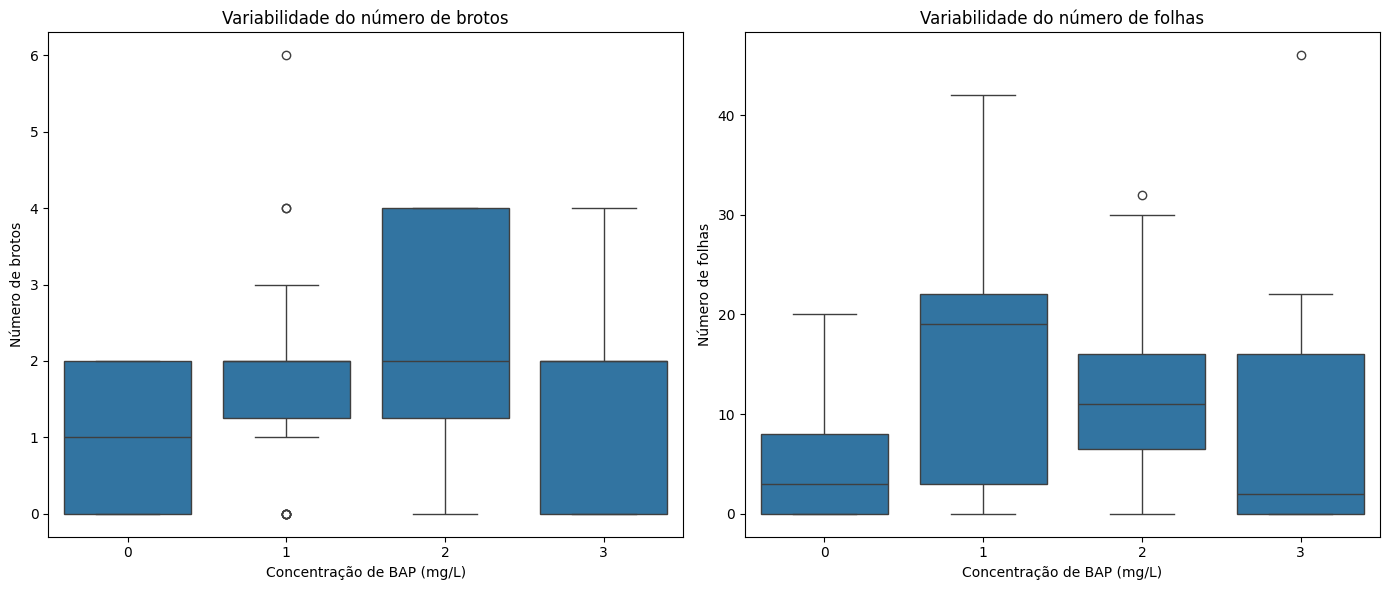

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot de brotos
sns.boxplot(
    data=df,
    x="Tratamento",
    y="Brotos",
    ax=axes[0]
)

axes[0].set_title("Variabilidade do número de brotos")
axes[0].set_xlabel("Concentração de BAP (mg/L)")
axes[0].set_ylabel("Número de brotos")

# Boxplot de folhas
sns.boxplot(
    data=df,
    x="Tratamento",
    y="Folhas",
    ax=axes[1]
)

axes[1].set_title("Variabilidade do número de folhas")
axes[1].set_xlabel("Concentração de BAP (mg/L)")
axes[1].set_ylabel("Número de folhas")

plt.tight_layout()
plt.show()

## 5 -  Existe diferença entre o controle e cada uma das doses de BAP?

R: Existe diferença significativa entre o controle e as doses de BAP para o número de brotos em todas as concentrações avaliadas (1, 2 e 3 mg). Para o número de folhas, também foram observadas diferenças significativas entre o controle e as concentrações de 1 e 2 mg de BAP. Entretanto, entre o controle e 3 mg de BAP não houve diferença significativa no número de folhas. Portanto, o efeito do BAP foi mais evidente para a formação de brotos, enquanto para folhas o efeito foi significativo apenas nas concentrações de 1 e 2 mg.

In [12]:
from scipy.stats import ttest_ind

In [13]:
import pandas as pd
from scipy.stats import ttest_ind

# Comparação do controle com cada dose de BAP - BROTOS

# Separar o controle (0 mg)
controle = df[df['Tratamento'] == 0]

# Comparar controle com cada concentração
for dose in [1, 2, 3]:
    tratamento = df[df['Tratamento'] == dose]

    #Teste para número de brotos
    t_brotos, p_brotos = ttest_ind (controle['Brotos'],tratamento['Brotos'],equal_var=False)

    # Teste para número de folhas
    t_folhas, p_folhas = ttest_ind(controle['Folhas'],tratamento['Folhas'],equal_var=False)

    print(f'\nControle (0 mg) × {dose} mg de BAP')
    print(f'Brotos: t = {t_brotos:.3f}, p = {p_brotos:.4f}')

    if p_brotos < 0.05:
        print('→ Diferença significativa nos brotos.')
    else:
        print('→ Não há diferença significativa nos brotos.')

    print(f'Folhas: t = {t_folhas:.3f}, p = {p_folhas:.4f}')

    if p_folhas < 0.05:
        print('→ Diferença significativa nas folhas.')
    else:
        print('→ Não há diferença significativa nas folhas.')


Controle (0 mg) × 1 mg de BAP
Brotos: t = -3.259, p = 0.0020
→ Diferença significativa nos brotos.
Folhas: t = -4.101, p = 0.0002
→ Diferença significativa nas folhas.

Controle (0 mg) × 2 mg de BAP
Brotos: t = -4.247, p = 0.0001
→ Diferença significativa nos brotos.
Folhas: t = -3.115, p = 0.0030
→ Diferença significativa nas folhas.

Controle (0 mg) × 3 mg de BAP
Brotos: t = -2.495, p = 0.0163
→ Diferença significativa nos brotos.
Folhas: t = -1.566, p = 0.1242
→ Não há diferença significativa nas folhas.


## 6 - Qual concentração produz maior e menor número de folhas?

R: A concentração de 1 mg de BAP apresentou o maior número médio de folhas (15 folhas), seguida por 2 mg (11,7) e 3 mg (9,07). O controle (0 mg) apresentou o menor número médio de folhas, com 5,4 folhas.



In [14]:
# Média de folhas por concentração de BAP

media_folhas = df.groupby("Tratamento")["Folhas"].mean()

print(media_folhas.round(2))

Tratamento
0     5.40
1    15.00
2    11.70
3     9.07
Name: Folhas, dtype: float64


In [15]:
 # Maior e menor média de folhas

maior = media_folhas.idxmax()
menor = media_folhas.idxmin()

print(f"Maior média de folhas: {maior} mg/L")
print(f"Menor média de folhas: {menor} mg/L")

print(f"Média máxima: {media_folhas.max():.2f}")
print(f"Média mínima: {media_folhas.min():.2f}")

Maior média de folhas: 1 mg/L
Menor média de folhas: 0 mg/L
Média máxima: 15.00
Média mínima: 5.40


## 7 - Existem tratamentos nos quais ocorre muita brotação, mas poucas folhas?

R: Sim existe, e podemos ver melhor a comparação com o gráfico abaixo, que relaciona quantidade de folhas e brotos, além de mostrar os tratamentos. Sendo assim o efeito do BAP não é necessariamente proporcional as duas características, onde, maior produção de brotos não significa necessariamente maior produção de folhas. EX: Numa repetição do tratamento 2 ocorreram 4 brotos, mas nenhum crescimento foliar.

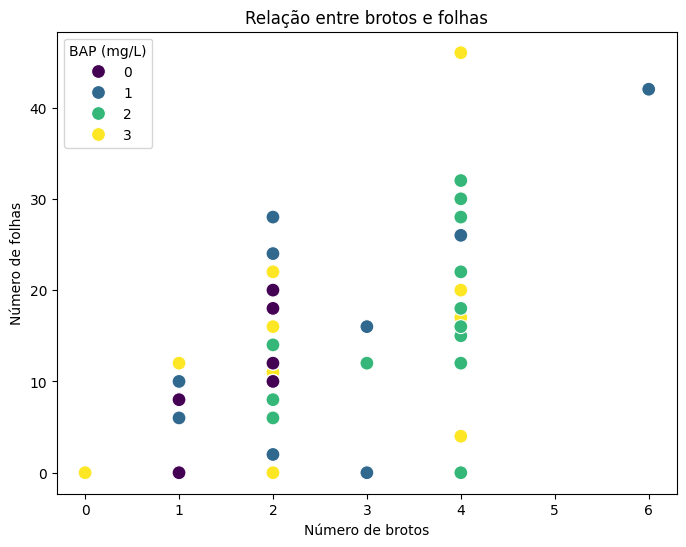

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Brotos",
    y="Folhas",
    hue="Tratamento",
    palette="viridis",
    s=100
)

plt.xlabel("Número de brotos")
plt.ylabel("Número de folhas")
plt.title("Relação entre brotos e folhas")
plt.legend(title="BAP (mg/L)")

plt.show()

## 8 - Calcule e compare a amplitude, a variância e o desvio-padrão do número de brotos e de folhas para cada concentração de BAP. Quais tratamentos apresentam maior variabilidade?

R: Ao comparar a variabilidade entre os tratamentos, observou-se que, para o número de brotos, o controle (0 mg) apresentou a menor variabilidade, com amplitude de 2, variância de 0,69 e desvio-padrão de 0,83. O tratamento com 2 mg apresentou a maior variabilidade, com variância de 2,27 e desvio-padrão de 1,51, seguido pelos tratamentos de 3 mg e 1 mg. Para o número de folhas, o controle também apresentou a menor variabilidade amplitude = 26; variância = 40,59; desvio-padrão = 6,37. Os tratamentos de 1 e 3 mg apresentaram as maiores variabilidades, sendo 3 mg um pouco superior, com variância de 123,86 e desvio-padrão de 11,13. Portanto, os tratamentos com BAP apresentaram maior dispersão dos dados em relação ao controle, especialmente 2 mg para brotos e 3 mg para folhas.


In [17]:
# Calculando amplitude, variância e desvio-padrão
# para cada concentração de BAP

resumo = df.groupby("Tratamento").agg(
    Min_Brotos=("Brotos", "min"),
    Max_Brotos=("Brotos", "max"),
    Var_Brotos=("Brotos", "var"),
    DP_Brotos=("Brotos", "std"),

    Min_Folhas=("Folhas", "min"),
    Max_Folhas=("Folhas", "max"),
    Var_Folhas=("Folhas", "var"),
    DP_Folhas=("Folhas", "std")
)

# Calculando as amplitudes
resumo["Amplitude_Brotos"] = (
    resumo["Max_Brotos"] - resumo["Min_Brotos"]
)

resumo["Amplitude_Folhas"] = (
    resumo["Max_Folhas"] - resumo["Min_Folhas"]
)

# Selecionando e organizando as colunas
resumo = resumo[
    [
        "Amplitude_Brotos",
        "Var_Brotos",
        "DP_Brotos",
        "Amplitude_Folhas",
        "Var_Folhas",
        "DP_Folhas"
    ]
]

print(resumo.round(2))

            Amplitude_Brotos  Var_Brotos  DP_Brotos  Amplitude_Folhas  \
Tratamento                                                              
0                          2        0.69       0.83                20   
1                          6        1.77       1.33                42   
2                          4        2.27       1.51                32   
3                          4        2.15       1.47                46   

            Var_Folhas  DP_Folhas  
Tratamento                         
0                40.59       6.37  
1               123.79      11.13  
2                82.15       9.06  
3               123.86      11.13  


## 9 - Calcule o coeficiente de variação (CV) para o número de brotos e de folhas em cada concentração de BAP.

R: Os coeficientes de variação indicam que houve elevada variabilidade nos dados, principalmente no controle e no tratamento com 3 mg de BAP. Para o número de brotos, o maior CV ocorreu no controle (88,68%), enquanto o menor foi observado em 2 mg (66,49%). Para o número de folhas, o maior CV foi encontrado em 3 mg (122,75%) e o menor em 1 mg (74,17%). Portanto, o tratamento de 2 mg apresentou maior homogeneidade para o número de brotos, enquanto 1 mg apresentou maior homogeneidade para o número de folhas.


In [18]:
# Coeficiente de variação (CV) para Brotos e Folhas

cv = df.groupby("Tratamento").agg(
    Media_Brotos=("Brotos", "mean"),
    DP_Brotos=("Brotos", "std"),
    Media_Folhas=("Folhas", "mean"),
    DP_Folhas=("Folhas", "std")
)

# Calculando o CV
cv["CV_Brotos"] = (cv["DP_Brotos"] / cv["Media_Brotos"]) * 100
cv["CV_Folhas"] = (cv["DP_Folhas"] / cv["Media_Folhas"]) * 100

# Mostrar somente os CVs
resultado_cv = cv[["CV_Brotos", "CV_Folhas"]]

print(resultado_cv.round(2))

            CV_Brotos  CV_Folhas
Tratamento                      
0               88.68     117.99
1               71.37      74.17
2               66.49      77.47
3               86.22     122.75


## 10 - Construa boxplots do número de brotos e para cada concentração de BAP. O que os boxplots mostram sobre a mediana, a dispersão e os possíveis valores atípicos?

R: Os boxplots mostram que a mediana do número de brotos é 1 no controle (0 mg) e 2 nas concentrações de 1, 2 e 3 mg de BAP, indicando maior número central de brotos nos tratamentos com BAP. A maior dispersão ocorre em 2 mg, que apresenta uma distribuição mais ampla dos valores. O tratamento de 1 mg apresenta menor dispersão dos valores centrais, mas possui valores atípicos, incluindo observações acima e abaixo do intervalo esperado. No controle e nos tratamentos de 2 e 3 mg, não foram observados valores atípicos evidentes. Portanto, os boxplots indicam diferenças na distribuição e na dispersão do número de brotos entre as concentrações de BAP, com destaque para a maior variabilidade em 2 mg.

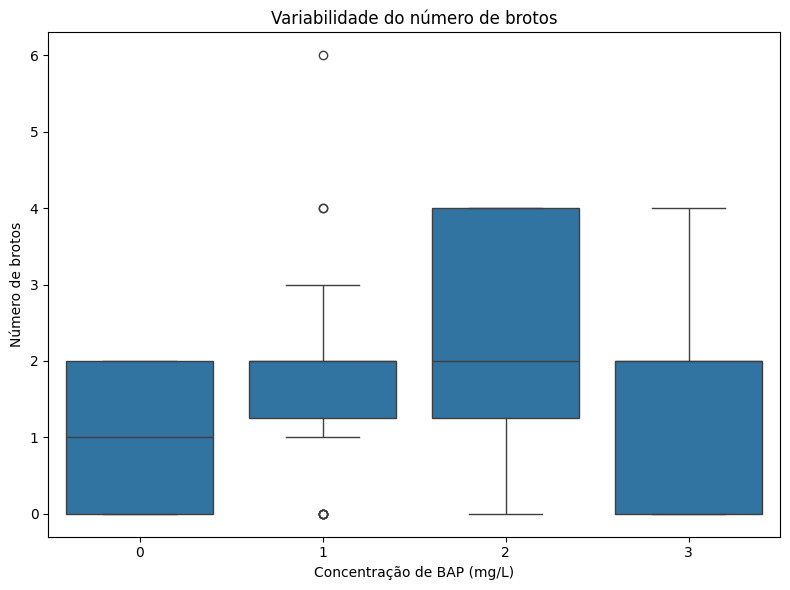

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Tratamento",
    y="Brotos",
    ax=ax
)

ax.set_title("Variabilidade do número de brotos")
ax.set_xlabel("Concentração de BAP (mg/L)")
ax.set_ylabel("Número de brotos")

plt.tight_layout()
plt.show()

## 11 - Analise a assimetria e a dispersão dos dados de brotos e folhas a partir dos boxplots. Em quais tratamentos os dados parecem mais concentrados ou mais dispersos?

R: Os boxplots mostram diferenças na assimetria e dispersão entre os tratamentos. Para os brotos, o tratamento de 2 mg de BAP apresenta maior dispersão, enquanto 1 mg concentra mais os valores em torno da mediana, apesar de apresentar alguns valores atípicos. O controle (0 mg) e 3 mg apresentam dispersão intermediária. Para as folhas, o tratamento de 1 mg apresenta os dados mais concentrados na região central, enquanto 0 mg e 3 mg apresentam maior dispersão. O tratamento de 3 mg também possui um valor atípico elevado. Em relação à assimetria, observa-se tendência de assimetria positiva (à direita) principalmente em 0 e 3 mg para folhas, devido à presença de valores mais altos, enquanto 1 mg apresenta maior concentração de valores na faixa superior. Portanto, 1 mg tende a apresentar maior concentração dos dados, enquanto 2 mg para brotos e 0 e 3 mg para folhas apresentam maior dispersão.

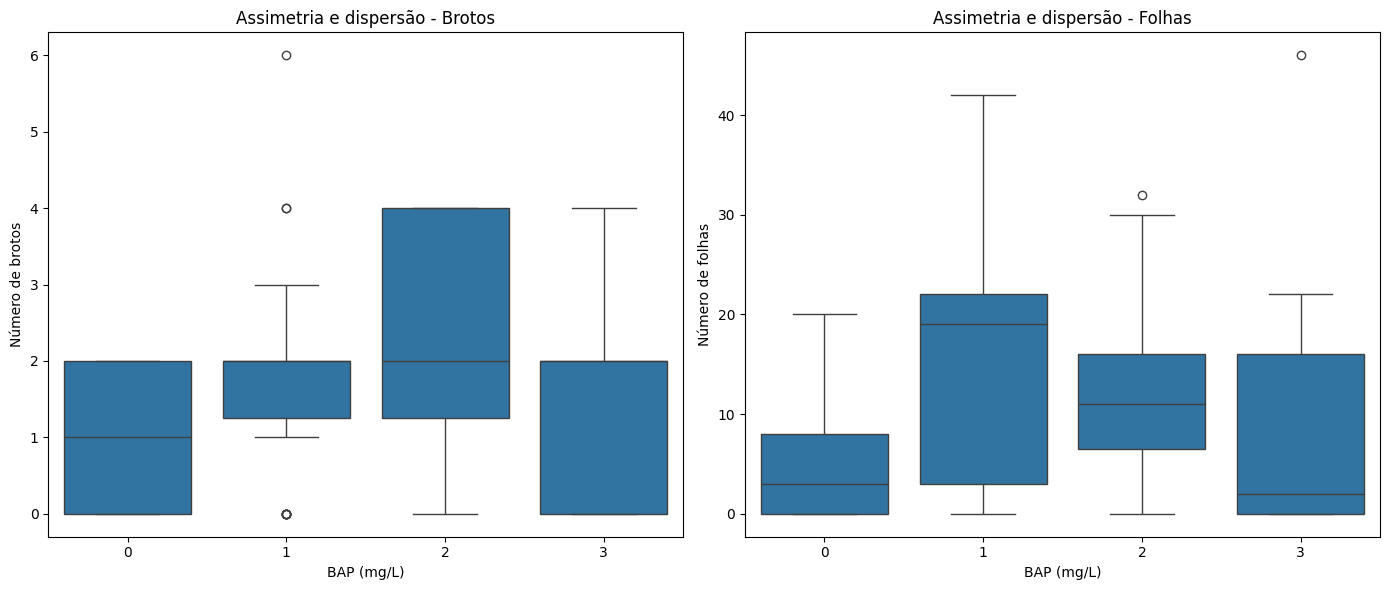

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x="Tratamento", y="Brotos", ax=axes[0])
axes[0].set_title("Assimetria e dispersão - Brotos")
axes[0].set_xlabel("BAP (mg/L)")
axes[0].set_ylabel("Número de brotos")

sns.boxplot(data=df, x="Tratamento", y="Folhas", ax=axes[1])
axes[1].set_title("Assimetria e dispersão - Folhas")
axes[1].set_xlabel("BAP (mg/L)")
axes[1].set_ylabel("Número de folhas")

plt.tight_layout()
plt.show()